# 09 — Persiapan Dataset untuk Modeling Machine Learning

## 1. Tujuan Tahap

Tahap ini bertujuan untuk menyiapkan dataset hasil labeling sentimen agar siap digunakan pada tahap modeling machine learning.

Fokus utama tahap ini adalah memastikan bahwa dataset yang akan digunakan untuk modeling sudah memenuhi syarat dasar, yaitu:

1. Dataset labeled berhasil dibaca dari folder `data/labeled/`.
2. Kolom utama untuk modeling tersedia dan valid.
3. Kolom teks bersih (`text_clean`) tersedia sebagai fitur utama.
4. Kolom label sentimen (`sentiment_label`) tersedia sebagai target.
5. Dataset dibersihkan dari data kosong yang dapat mengganggu proses modeling.
6. Label target dinormalisasi agar konsisten.
7. Distribusi target diperiksa kembali sebelum proses training model.
8. Dataset siap modeling disimpan secara lokal ke folder `data/modeling/`.

Pada tahap ini belum dilakukan training model machine learning. Tahap ini hanya berfokus pada persiapan dataset agar proses modeling pada tahap berikutnya dapat dilakukan secara lebih terstruktur, aman, dan dapat dipertanggungjawabkan secara akademik.

## 2. Output yang Dihasilkan

Output yang diharapkan dari Tahap 09 adalah:

1. Dataset labeled berhasil dimuat sebagai input awal.
2. Informasi dataset labeled terbaru berhasil dideteksi dari folder `data/labeled/`.
3. Validasi kolom utama berhasil dilakukan.
4. Dataset awal untuk modeling berhasil disiapkan menggunakan kolom fitur dan target.
5. Data kosong pada kolom `text_clean` berhasil diidentifikasi dan dibersihkan.
6. Label target berhasil dinormalisasi.
7. Distribusi target setelah pembersihan berhasil dianalisis.
8. Dataset siap modeling disimpan secara lokal ke folder `data/modeling/`.
9. Metadata dan laporan ringkasan aman disimpan ke folder `reports/`.
10. Checklist keamanan file sebelum push ke GitHub tersedia.

Catatan keamanan:

- Notebook boleh dipublikasikan ke GitHub.
- Laporan ringkasan dan metadata aman boleh dipublikasikan ke GitHub.
- Dataset pada folder `data/raw/`, `data/processed/`, `data/labeled/`, dan `data/modeling/` tidak boleh dipublikasikan ke GitHub.
- File `.env` tidak boleh dibaca, ditampilkan, atau dipublikasikan.
- Kolom `author` tidak boleh ditampilkan.

## 3. Konsep Persiapan Dataset Modeling

Dalam konteks machine learning, dataset yang akan digunakan untuk modeling harus melewati tahap persiapan agar data yang masuk ke model memiliki struktur yang jelas, bersih, dan konsisten.

Pada project analisis sentimen ini, dataset hasil labeling memiliki dua komponen utama:

1. **Fitur (X)**  
   Fitur adalah data input yang digunakan oleh model untuk mempelajari pola.  
   Pada project ini, fitur utama yang digunakan adalah teks hasil preprocessing pada kolom `text_clean`.

2. **Target (y)**  
   Target adalah label yang akan diprediksi oleh model.  
   Pada project ini, target yang digunakan adalah kolom `sentiment_label`, yang berisi kategori:
   - `positif`
   - `negatif`
   - `netral`

Tahap persiapan dataset modeling perlu dilakukan karena model machine learning membutuhkan data dengan format yang konsisten. Data kosong, label yang tidak seragam, atau struktur kolom yang tidak lengkap dapat menyebabkan error pada saat training model.

Secara alur CRISP-DM, tahap ini termasuk dalam fase **Data Preparation**, yaitu fase untuk menyiapkan data sebelum masuk ke tahap **Modeling**.

In [1]:
# ============================================================
# 09 - Modeling Dataset Preparation
# Bagian 1: Import Library
# ============================================================

from pathlib import Path
from datetime import datetime
from IPython.display import display

import warnings
import pandas as pd
import numpy as np

# Menghilangkan warning yang tidak kritikal agar output notebook lebih bersih
warnings.filterwarnings("ignore")

print("Library berhasil di-import.")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Library berhasil di-import.
Pandas version: 3.0.3
NumPy version: 2.4.6


In [2]:
# ============================================================
# Deteksi Project Root
# ============================================================
# Tujuan:
# Mendeteksi folder utama project secara otomatis, baik notebook
# dijalankan dari folder root maupun dari folder notebooks/.
#
# Catatan keamanan:
# Cell ini tidak membaca file .env dan tidak menampilkan API key.
# ============================================================

def find_project_root(start_path=None):
    """
    Mencari root folder project berdasarkan keberadaan folder 'data'
    dan 'notebooks'.

    Parameters
    ----------
    start_path : str atau Path, optional
        Lokasi awal pencarian. Jika None, menggunakan current working directory.

    Returns
    -------
    Path
        Path root project.
    """
    current_path = Path.cwd() if start_path is None else Path(start_path)
    current_path = current_path.resolve()

    # Cek current directory dan seluruh parent directory
    for candidate in [current_path, *current_path.parents]:
        has_data_dir = (candidate / "data").is_dir()
        has_notebooks_dir = (candidate / "notebooks").is_dir()

        if has_data_dir and has_notebooks_dir:
            return candidate

    raise FileNotFoundError(
        "Project root tidak ditemukan. Pastikan notebook berada di dalam struktur project "
        "yang memiliki folder 'data' dan 'notebooks'."
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
LABELED_DIR = DATA_DIR / "labeled"
MODELING_DIR = DATA_DIR / "modeling"
REPORTS_DIR = PROJECT_ROOT / "reports"

print("Project root berhasil dideteksi.")
print("Project root:", PROJECT_ROOT)
print("Folder data:", DATA_DIR)
print("Folder labeled:", LABELED_DIR)
print("Folder reports:", REPORTS_DIR)

Project root berhasil dideteksi.
Project root: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis
Folder data: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data
Folder labeled: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\labeled
Folder reports: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports


In [3]:
# ============================================================
# Validasi Folder Input
# ============================================================
# Folder yang wajib tersedia pada tahap awal ini:
# 1. data/labeled/
# 2. reports/
#
# Folder data/modeling/ akan dibuat pada bagian berikutnya
# ketika dataset siap modeling akan disimpan.
# ============================================================

required_dirs = {
    "data": DATA_DIR,
    "labeled": LABELED_DIR,
    "reports": REPORTS_DIR
}

for dir_name, dir_path in required_dirs.items():
    if not dir_path.exists():
        raise FileNotFoundError(f"Folder wajib tidak ditemukan: {dir_name} -> {dir_path}")

print("Validasi folder berhasil.")
print("Folder input utama tersedia.")

Validasi folder berhasil.
Folder input utama tersedia.


In [4]:
# ============================================================
# Deteksi Dataset Labeled Terbaru
# ============================================================
# Dataset labeled dibaca dari folder data/labeled/.
# File yang didukung:
# - CSV
# - Excel
# - Parquet
#
# Catatan:
# Cell ini hanya mendeteksi file terbaru berdasarkan waktu modifikasi.
# ============================================================

SUPPORTED_EXTENSIONS = [".csv", ".xlsx", ".xls", ".parquet"]

labeled_files = [
    file_path
    for file_path in LABELED_DIR.iterdir()
    if file_path.is_file()
    and file_path.suffix.lower() in SUPPORTED_EXTENSIONS
    and not file_path.name.startswith("~$")
]

if len(labeled_files) == 0:
    raise FileNotFoundError(
        f"Tidak ada file dataset labeled yang ditemukan di folder: {LABELED_DIR}"
    )

# Urutkan file berdasarkan waktu modifikasi terbaru
labeled_files_sorted = sorted(
    labeled_files,
    key=lambda file_path: file_path.stat().st_mtime,
    reverse=True
)

latest_labeled_file = labeled_files_sorted[0]
latest_modified_time = datetime.fromtimestamp(
    latest_labeled_file.stat().st_mtime
).strftime("%Y-%m-%d %H:%M:%S")

print("Jumlah file dataset labeled ditemukan:", len(labeled_files_sorted))
print("File dataset labeled terbaru:")
print(latest_labeled_file.name)
print("Waktu modifikasi file terbaru:")
print(latest_modified_time)

# Tampilkan ringkasan file secara aman tanpa membuka isi dataset
file_summary = pd.DataFrame({
    "informasi": [
        "Nama file labeled terbaru",
        "Ekstensi file",
        "Waktu modifikasi",
        "Ukuran file (KB)"
    ],
    "nilai": [
        latest_labeled_file.name,
        latest_labeled_file.suffix.lower(),
        latest_modified_time,
        round(latest_labeled_file.stat().st_size / 1024, 2)
    ]
})

display(file_summary)

Jumlah file dataset labeled ditemukan: 1
File dataset labeled terbaru:
youtube_comments_labeled_20260529_153650.csv
Waktu modifikasi file terbaru:
2026-05-29 15:37:10


,informasi,nilai
0,Nama file labeled terbaru,youtube_comments_labeled_20260529_153650.csv
1,Ekstensi file,.csv
2,Waktu modifikasi,2026-05-29 15:37:10
3,Ukuran file (KB),1978.0


In [5]:
# ============================================================
# Load Dataset Labeled Secara Aman
# ============================================================
# Dataset dibaca sebagai input awal untuk persiapan modeling.
#
# Catatan keamanan:
# - Tidak membaca file .env.
# - Tidak menampilkan API key.
# - Tidak menampilkan kolom author.
# - Tidak menampilkan isi komentar pada tahap ini.
# ============================================================

def load_dataset_safely(file_path):
    """
    Membaca dataset berdasarkan ekstensi file.

    Parameters
    ----------
    file_path : Path
        Lokasi file dataset.

    Returns
    -------
    pd.DataFrame
        Dataset dalam bentuk DataFrame.
    """
    file_extension = file_path.suffix.lower()

    if file_extension == ".csv":
        try:
            return pd.read_csv(file_path)
        except UnicodeDecodeError:
            return pd.read_csv(file_path, encoding="utf-8-sig")

    elif file_extension in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)

    elif file_extension == ".parquet":
        return pd.read_parquet(file_path)

    else:
        raise ValueError(f"Format file tidak didukung: {file_extension}")


df_labeled = load_dataset_safely(latest_labeled_file)

print("Dataset labeled berhasil dibaca.")
print("Nama file:", latest_labeled_file.name)
print("Jumlah baris:", df_labeled.shape[0])
print("Jumlah kolom:", df_labeled.shape[1])
print("Isi komentar tidak ditampilkan pada tahap ini.")

Dataset labeled berhasil dibaca.
Nama file: youtube_comments_labeled_20260529_153650.csv
Jumlah baris: 3670
Jumlah kolom: 24
Isi komentar tidak ditampilkan pada tahap ini.


In [6]:
# ============================================================
# Validasi Kolom Utama
# ============================================================
# Kolom utama yang wajib tersedia:
# 1. text_original
# 2. text_clean
# 3. sentiment_label
#
# Catatan:
# Pada tahap ini, kita hanya memvalidasi ketersediaan kolom.
# Validasi detail label target akan dilakukan pada bagian berikutnya.
# ============================================================

required_columns = ["text_original", "text_clean", "sentiment_label"]

available_columns = list(df_labeled.columns)
missing_columns = [col for col in required_columns if col not in available_columns]

validation_result = pd.DataFrame({
    "kolom_wajib": required_columns,
    "status": [
        "Tersedia" if col in available_columns else "Tidak tersedia"
        for col in required_columns
    ]
})

display(validation_result)

if missing_columns:
    raise KeyError(
        f"Validasi gagal. Kolom wajib berikut tidak tersedia: {missing_columns}"
    )

print("Validasi berhasil.")
print("Semua kolom utama untuk persiapan modeling tersedia.")

,kolom_wajib,status
0,text_original,Tersedia
1,text_clean,Tersedia
2,sentiment_label,Tersedia


Validasi berhasil.
Semua kolom utama untuk persiapan modeling tersedia.


In [7]:
# ============================================================
# Tinjauan Struktur Dataset Secara Aman
# ============================================================
# Tujuan:
# Menampilkan struktur dataset tanpa menampilkan isi komentar,
# tanpa menampilkan kolom author, dan tanpa informasi sensitif.
# ============================================================

sensitive_column_keywords = [
    "author",
    "email",
    "api",
    "key",
    "token"
]

def is_sensitive_column(column_name):
    """
    Mengecek apakah nama kolom berpotensi sensitif.
    """
    column_name_lower = column_name.lower()
    return any(keyword in column_name_lower for keyword in sensitive_column_keywords)


safe_columns = [
    col for col in df_labeled.columns
    if not is_sensitive_column(col)
]

hidden_columns = [
    col for col in df_labeled.columns
    if is_sensitive_column(col)
]

structure_summary = pd.DataFrame({
    "metrik": [
        "Jumlah baris",
        "Jumlah kolom total",
        "Jumlah kolom aman ditinjau",
        "Jumlah kolom disembunyikan",
        "Jumlah nilai kosong text_clean",
        "Jumlah nilai kosong sentiment_label",
        "Jumlah duplikasi text_clean"
    ],
    "nilai": [
        df_labeled.shape[0],
        df_labeled.shape[1],
        len(safe_columns),
        len(hidden_columns),
        df_labeled["text_clean"].isna().sum(),
        df_labeled["sentiment_label"].isna().sum(),
        df_labeled["text_clean"].duplicated().sum()
    ]
})

display(structure_summary)

print("Daftar kolom aman untuk ditinjau:")
display(pd.DataFrame({"kolom_aman": safe_columns}))

if hidden_columns:
    print("Kolom yang disembunyikan karena berpotensi sensitif:")
    display(pd.DataFrame({"kolom_disembunyikan": hidden_columns}))
else:
    print("Tidak ada kolom sensitif yang terdeteksi berdasarkan nama kolom.")

,metrik,nilai
0,Jumlah baris,3670
1,Jumlah kolom total,24
2,Jumlah kolom aman ditinjau,24
3,Jumlah kolom disembunyikan,0
4,Jumlah nilai kosong text_clean,0
5,Jumlah nilai kosong sentiment_label,0
6,Jumlah duplikasi text_clean,9


Daftar kolom aman untuk ditinjau:


,kolom_aman
0,video_id
1,video_title
2,video_url
3,channel_title
4,video_published_at
5,comment_id
6,published_at
7,comment_updated_at
8,text_original
9,like_count


Tidak ada kolom sensitif yang terdeteksi berdasarkan nama kolom.


## 4. Interpretasi Awal

Berdasarkan hasil validasi awal, dataset labeled telah berhasil dimuat dari folder `data/labeled/`. Kolom utama yang dibutuhkan untuk persiapan modeling, yaitu `text_original`, `text_clean`, dan `sentiment_label`, juga telah divalidasi.

Pada tahap ini, isi komentar belum ditampilkan untuk menjaga keamanan dan etika penggunaan data. Kolom yang berpotensi sensitif seperti `author` juga tidak ditampilkan.

Dengan demikian, dataset sudah dapat dilanjutkan ke proses berikutnya, yaitu:

1. validasi nilai label target,
2. pemilihan kolom fitur dan target,
3. pembersihan data kosong pada `text_clean`,
4. normalisasi label target,
5. pemeriksaan distribusi target setelah pembersihan,
6. penyimpanan dataset siap modeling ke folder lokal `data/modeling/`.

## 5. Validasi Label Target

Pada tahap ini dilakukan validasi terhadap kolom target `sentiment_label`.

Validasi label target penting dilakukan karena model machine learning hanya dapat belajar dengan baik apabila label target memiliki struktur yang konsisten.

Label yang diharapkan pada project ini adalah:

1. `positif`
2. `negatif`
3. `netral`

Jika ditemukan label di luar tiga kategori tersebut, maka data perlu diperiksa kembali sebelum masuk ke tahap modeling.

In [8]:
# ============================================================
# Validasi Label Target
# ============================================================
# Tujuan:
# Memastikan bahwa kolom sentiment_label hanya berisi label:
# - positif
# - negatif
# - netral
#
# Catatan:
# Pada tahap ini belum dilakukan training model.
# ============================================================

TARGET_COLUMN = "sentiment_label"

expected_labels = {"positif", "negatif", "netral"}

# Ambil label unik sebelum normalisasi
unique_labels_raw = (
    df_labeled[TARGET_COLUMN]
    .dropna()
    .astype(str)
    .unique()
)

unique_labels_raw_sorted = sorted(unique_labels_raw)

print("Label unik sebelum normalisasi:")
display(pd.DataFrame({"label_unik": unique_labels_raw_sorted}))

# Normalisasi sementara untuk keperluan validasi
normalized_labels_check = (
    df_labeled[TARGET_COLUMN]
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
)

unique_labels_normalized = set(normalized_labels_check.unique())

invalid_labels = sorted(list(unique_labels_normalized - expected_labels))
missing_expected_labels = sorted(list(expected_labels - unique_labels_normalized))

label_validation_summary = pd.DataFrame({
    "pemeriksaan": [
        "Jumlah label unik setelah normalisasi",
        "Label yang diharapkan",
        "Label tidak valid",
        "Label yang belum ditemukan"
    ],
    "hasil": [
        len(unique_labels_normalized),
        ", ".join(sorted(expected_labels)),
        ", ".join(invalid_labels) if invalid_labels else "Tidak ada",
        ", ".join(missing_expected_labels) if missing_expected_labels else "Tidak ada"
    ]
})

display(label_validation_summary)

if invalid_labels:
    raise ValueError(
        f"Ditemukan label tidak valid: {invalid_labels}. "
        "Silakan periksa kembali proses labeling sebelum modeling."
    )

print("Validasi label target berhasil.")
print("Label target hanya berisi kategori yang diharapkan.")

Label unik sebelum normalisasi:


,label_unik
0,negatif
1,netral
2,positif


,pemeriksaan,hasil
0,Jumlah label unik setelah normalisasi,3
1,Label yang diharapkan,"negatif, netral, positif"
2,Label tidak valid,Tidak ada
3,Label yang belum ditemukan,Tidak ada


Validasi label target berhasil.
Label target hanya berisi kategori yang diharapkan.


## 6. Pemilihan Kolom Fitur dan Target

Pada tahap modeling machine learning, dataset perlu dipisahkan menjadi fitur dan target.

Dalam project ini:

- Fitur utama (`X`) adalah kolom `text_clean`.
- Target (`y`) adalah kolom `sentiment_label`.

Kolom `text_clean` digunakan karena sudah melewati proses cleaning dan preprocessing teks. Sementara itu, kolom `sentiment_label` digunakan sebagai label kelas yang akan diprediksi oleh model pada tahap berikutnya.

Kolom lain seperti `author` tidak digunakan dan tidak ditampilkan karena berpotensi memuat informasi sensitif.

In [9]:
# ============================================================
# Pemilihan Kolom Fitur dan Target
# ============================================================
# Fitur utama:
# - text_clean
#
# Target:
# - sentiment_label
#
# Catatan keamanan:
# - Kolom author tidak digunakan.
# - text_original tidak digunakan untuk modeling preparation akhir.
# - Dataset modeling dibuat seminimal mungkin.
# ============================================================

FEATURE_COLUMN = "text_clean"
TARGET_COLUMN = "sentiment_label"

modeling_columns = [FEATURE_COLUMN, TARGET_COLUMN]

df_modeling = df_labeled[modeling_columns].copy()

print("Dataset awal untuk modeling berhasil dibuat.")
print("Jumlah baris awal:", df_modeling.shape[0])
print("Jumlah kolom:", df_modeling.shape[1])

display(pd.DataFrame({
    "kolom_modeling": modeling_columns,
    "peran": ["Fitur teks", "Target sentimen"]
}))

Dataset awal untuk modeling berhasil dibuat.
Jumlah baris awal: 3670
Jumlah kolom: 2


,kolom_modeling,peran
0,text_clean,Fitur teks
1,sentiment_label,Target sentimen


## 7. Pembersihan Dataset untuk Kebutuhan Modeling

Sebelum dataset digunakan untuk modeling, beberapa pembersihan dasar perlu dilakukan, yaitu:

1. Menghapus data dengan nilai kosong pada `text_clean`.
2. Menghapus data dengan nilai kosong pada `sentiment_label`.
3. Menghapus teks yang hanya berisi spasi kosong.
4. Menormalisasi label target agar seluruh label menggunakan format huruf kecil.
5. Menghapus duplikasi pada pasangan `text_clean` dan `sentiment_label`.

Pembersihan ini dilakukan agar dataset yang masuk ke tahap modeling lebih konsisten dan mengurangi risiko error pada proses training model di tahap berikutnya.

In [10]:
# ============================================================
# Pembersihan Dataset untuk Modeling
# ============================================================
# Proses:
# 1. Konversi text_clean menjadi string
# 2. Hilangkan leading/trailing spaces
# 3. Ubah string kosong menjadi NaN
# 4. Drop missing values pada fitur dan target
# 5. Normalisasi label target
# 6. Validasi ulang label
# ============================================================

initial_rows = df_modeling.shape[0]

# Pastikan kolom fitur dan target tidak bermasalah
df_modeling[FEATURE_COLUMN] = df_modeling[FEATURE_COLUMN].astype("string")
df_modeling[TARGET_COLUMN] = df_modeling[TARGET_COLUMN].astype("string")

# Bersihkan spasi di awal dan akhir teks
df_modeling[FEATURE_COLUMN] = df_modeling[FEATURE_COLUMN].str.strip()
df_modeling[TARGET_COLUMN] = df_modeling[TARGET_COLUMN].str.strip().str.lower()

# Ubah string kosong menjadi nilai kosong
df_modeling[FEATURE_COLUMN] = df_modeling[FEATURE_COLUMN].replace("", pd.NA)
df_modeling[TARGET_COLUMN] = df_modeling[TARGET_COLUMN].replace("", pd.NA)

missing_text_before = df_modeling[FEATURE_COLUMN].isna().sum()
missing_label_before = df_modeling[TARGET_COLUMN].isna().sum()

# Hapus baris yang tidak memiliki fitur atau target
df_modeling_clean = df_modeling.dropna(
    subset=[FEATURE_COLUMN, TARGET_COLUMN]
).copy()

# Validasi ulang label setelah normalisasi
invalid_labels_after_cleaning = sorted(
    list(set(df_modeling_clean[TARGET_COLUMN].unique()) - expected_labels)
)

if invalid_labels_after_cleaning:
    raise ValueError(
        f"Masih ditemukan label tidak valid setelah pembersihan: {invalid_labels_after_cleaning}"
    )

rows_after_dropna = df_modeling_clean.shape[0]

print("Pembersihan nilai kosong selesai.")
print("Jumlah baris awal:", initial_rows)
print("Jumlah text_clean kosong sebelum pembersihan:", missing_text_before)
print("Jumlah sentiment_label kosong sebelum pembersihan:", missing_label_before)
print("Jumlah baris setelah drop nilai kosong:", rows_after_dropna)
print("Jumlah baris terhapus karena nilai kosong:", initial_rows - rows_after_dropna)

Pembersihan nilai kosong selesai.
Jumlah baris awal: 3670
Jumlah text_clean kosong sebelum pembersihan: 0
Jumlah sentiment_label kosong sebelum pembersihan: 0
Jumlah baris setelah drop nilai kosong: 3670
Jumlah baris terhapus karena nilai kosong: 0


In [11]:
# ============================================================
# Penghapusan Duplikasi Dataset Modeling
# ============================================================
# Duplikasi yang dicek adalah kombinasi:
# - text_clean
# - sentiment_label
#
# Tujuan:
# Mengurangi pengulangan data yang sama persis pada dataset modeling.
# ============================================================

rows_before_deduplication = df_modeling_clean.shape[0]

duplicate_count = df_modeling_clean.duplicated(
    subset=[FEATURE_COLUMN, TARGET_COLUMN]
).sum()

df_modeling_clean = df_modeling_clean.drop_duplicates(
    subset=[FEATURE_COLUMN, TARGET_COLUMN]
).reset_index(drop=True)

rows_after_deduplication = df_modeling_clean.shape[0]

print("Pemeriksaan duplikasi selesai.")
print("Jumlah baris sebelum penghapusan duplikasi:", rows_before_deduplication)
print("Jumlah duplikasi ditemukan:", duplicate_count)
print("Jumlah baris setelah penghapusan duplikasi:", rows_after_deduplication)
print("Jumlah baris akhir dataset modeling:", df_modeling_clean.shape[0])

Pemeriksaan duplikasi selesai.
Jumlah baris sebelum penghapusan duplikasi: 3670
Jumlah duplikasi ditemukan: 9
Jumlah baris setelah penghapusan duplikasi: 3661
Jumlah baris akhir dataset modeling: 3661


In [12]:
# ============================================================
# Pemeriksaan Distribusi Target Setelah Pembersihan
# ============================================================
# Tujuan:
# Melihat apakah distribusi label masih tidak seimbang
# setelah data kosong dan duplikasi dihapus.
# ============================================================

target_distribution = (
    df_modeling_clean[TARGET_COLUMN]
    .value_counts()
    .rename_axis("sentiment_label")
    .reset_index(name="jumlah")
)

target_distribution["persentase"] = (
    target_distribution["jumlah"] / target_distribution["jumlah"].sum() * 100
).round(2)

display(target_distribution)

dominant_label = target_distribution.iloc[0]["sentiment_label"]
dominant_count = target_distribution.iloc[0]["jumlah"]
dominant_percentage = target_distribution.iloc[0]["persentase"]

minority_label = target_distribution.iloc[-1]["sentiment_label"]
minority_count = target_distribution.iloc[-1]["jumlah"]
minority_percentage = target_distribution.iloc[-1]["persentase"]

imbalance_ratio = round(dominant_count / minority_count, 2) if minority_count > 0 else np.nan

summary_distribution = pd.DataFrame({
    "metrik": [
        "Total data siap modeling",
        "Label dominan",
        "Jumlah label dominan",
        "Persentase label dominan",
        "Label minoritas",
        "Jumlah label minoritas",
        "Persentase label minoritas",
        "Rasio dominan terhadap minoritas"
    ],
    "nilai": [
        df_modeling_clean.shape[0],
        dominant_label,
        dominant_count,
        f"{dominant_percentage}%",
        minority_label,
        minority_count,
        f"{minority_percentage}%",
        imbalance_ratio
    ]
})

display(summary_distribution)

,sentiment_label,jumlah,persentase
0,netral,2416,65.99
1,negatif,637,17.4
2,positif,608,16.61


,metrik,nilai
0,Total data siap modeling,3661
1,Label dominan,netral
2,Jumlah label dominan,2416
3,Persentase label dominan,65.99%
4,Label minoritas,positif
5,Jumlah label minoritas,608
6,Persentase label minoritas,16.61%
7,Rasio dominan terhadap minoritas,3.97


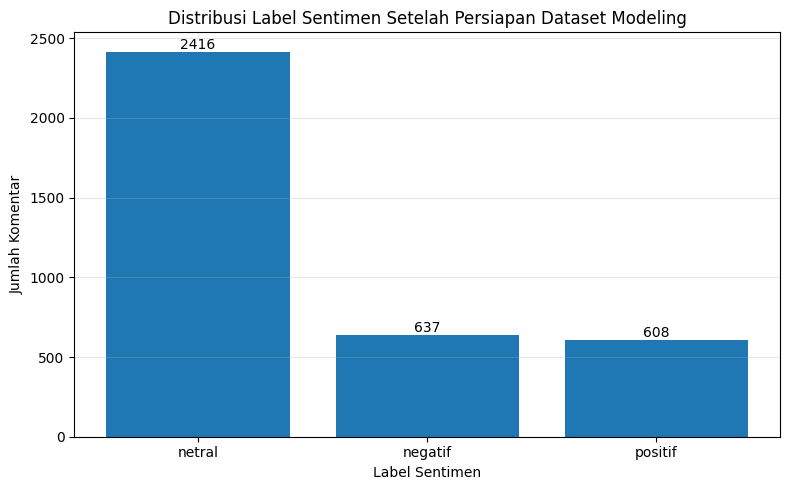

In [13]:
# ============================================================
# Visualisasi Distribusi Target
# ============================================================
# Visualisasi ini aman karena hanya menampilkan agregasi label,
# bukan isi komentar.
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    target_distribution["sentiment_label"],
    target_distribution["jumlah"]
)

plt.title("Distribusi Label Sentimen Setelah Persiapan Dataset Modeling")
plt.xlabel("Label Sentimen")
plt.ylabel("Jumlah Komentar")
plt.grid(axis="y", alpha=0.3)

for index, row in target_distribution.iterrows():
    plt.text(
        index,
        row["jumlah"],
        str(row["jumlah"]),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# Sampel Aman Dataset Modeling
# ============================================================
# Catatan keamanan:
# - Sampel dibatasi.
# - Teks dipotong maksimal 120 karakter.
# - Tidak menampilkan kolom author.
# - Tidak menampilkan text_original.
# ============================================================

def truncate_text(text, max_length=120):
    """
    Memotong teks agar aman ditampilkan pada notebook.
    """
    text = str(text)
    if len(text) <= max_length:
        return text
    return text[:max_length] + "..."

safe_sample = df_modeling_clean.sample(
    n=min(5, len(df_modeling_clean)),
    random_state=42
).copy()

safe_sample["text_clean_preview"] = safe_sample[FEATURE_COLUMN].apply(
    lambda x: truncate_text(x, max_length=120)
)

safe_sample_display = safe_sample[["text_clean_preview", TARGET_COLUMN]]

display(safe_sample_display)

print("Sampel aman berhasil ditampilkan.")
print("Jumlah sampel ditampilkan:", len(safe_sample_display))

,text_clean_preview,sentiment_label
291,bakso is inspirasi,netral
270,yang menjadi pangkal persoalan adalah sistem v...,netral
149,halo saya dari 2024 sekarang dolar sudah sampe...,netral
1188,freelancer indonesia ngacung hehe kita bantu m...,positif
2037,rupiah melemah bukan berarti ekonomi kita hanc...,negatif


Sampel aman berhasil ditampilkan.
Jumlah sampel ditampilkan: 5


## 8. Interpretasi Distribusi Target Setelah Pembersihan

Setelah dilakukan pembersihan data untuk kebutuhan modeling, distribusi label target diperiksa kembali.

Pemeriksaan ini penting karena distribusi target yang tidak seimbang dapat memengaruhi performa model machine learning. Jika satu label terlalu dominan, model dapat cenderung memprediksi kelas dominan dan kurang sensitif terhadap kelas minoritas.

Berdasarkan hasil distribusi target, informasi yang perlu diperhatikan adalah:

1. label yang paling dominan,
2. label yang paling sedikit,
3. rasio antara label dominan dan label minoritas,
4. potensi kebutuhan strategi evaluasi yang lebih tepat pada tahap modeling.

Pada tahap modeling berikutnya, evaluasi model tidak cukup hanya menggunakan accuracy. Metrik seperti precision, recall, dan F1-score perlu digunakan agar performa model dapat dianalisis secara lebih adil pada setiap kelas sentimen.

In [15]:
# ============================================================
# Membuat Folder Output Lokal
# ============================================================
# Folder data/modeling/ digunakan untuk menyimpan dataset siap modeling.
#
# Catatan:
# Folder ini bersifat lokal dan tidak boleh dipublikasikan ke GitHub.
# ============================================================

MODELING_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Folder output berhasil disiapkan.")
print("Folder modeling:", MODELING_DIR)
print("Folder reports:", REPORTS_DIR)

Folder output berhasil disiapkan.
Folder modeling: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\modeling
Folder reports: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports


In [16]:
# ============================================================
# Simpan Dataset Siap Modeling
# ============================================================
# Dataset ini tetap memuat teks komentar hasil preprocessing,
# sehingga hanya boleh disimpan secara lokal.
#
# Jangan push folder data/modeling/ ke GitHub.
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

modeling_dataset_filename = f"youtube_comments_modeling_ready_{timestamp}.csv"
modeling_dataset_path = MODELING_DIR / modeling_dataset_filename

df_modeling_clean.to_csv(
    modeling_dataset_path,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset siap modeling berhasil disimpan secara lokal.")
print("Nama file:", modeling_dataset_filename)
print("Lokasi:", modeling_dataset_path)
print("Jumlah baris:", df_modeling_clean.shape[0])
print("Jumlah kolom:", df_modeling_clean.shape[1])
print("Catatan: file ini tidak boleh dipublikasikan ke GitHub.")

Dataset siap modeling berhasil disimpan secara lokal.
Nama file: youtube_comments_modeling_ready_20260529_171713.csv
Lokasi: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\modeling\youtube_comments_modeling_ready_20260529_171713.csv
Jumlah baris: 3661
Jumlah kolom: 2
Catatan: file ini tidak boleh dipublikasikan ke GitHub.


In [17]:
# ============================================================
# Simpan Metadata Aman
# ============================================================
# Metadata ini tidak memuat isi komentar.
# Metadata aman untuk dokumentasi dan dapat dipush ke GitHub.
# ============================================================

metadata = {
    "stage": "09_modeling_dataset_preparation",
    "project_title": "Analisis Sentimen Komentar YouTube terhadap Isu Pelemahan Nilai Rupiah",
    "source_file": latest_labeled_file.name,
    "source_file_modified_time": latest_modified_time,
    "output_modeling_file": modeling_dataset_filename,
    "created_at": timestamp,
    "feature_column": FEATURE_COLUMN,
    "target_column": TARGET_COLUMN,
    "initial_rows": int(initial_rows),
    "rows_after_dropna": int(rows_after_dropna),
    "duplicate_rows_removed": int(duplicate_count),
    "final_rows": int(df_modeling_clean.shape[0]),
    "final_columns": int(df_modeling_clean.shape[1]),
    "allowed_labels": sorted(list(expected_labels)),
    "dominant_label": str(dominant_label),
    "dominant_count": int(dominant_count),
    "dominant_percentage": float(dominant_percentage),
    "minority_label": str(minority_label),
    "minority_count": int(minority_count),
    "minority_percentage": float(minority_percentage),
    "imbalance_ratio": float(imbalance_ratio)
}

metadata_df = pd.DataFrame(
    list(metadata.items()),
    columns=["metadata", "value"]
)

metadata_filename = f"metadata_09_modeling_dataset_preparation_{timestamp}.csv"
metadata_path = REPORTS_DIR / metadata_filename

metadata_df.to_csv(
    metadata_path,
    index=False,
    encoding="utf-8-sig"
)

print("Metadata aman berhasil disimpan.")
print("Nama file:", metadata_filename)
print("Lokasi:", metadata_path)

display(metadata_df)

Metadata aman berhasil disimpan.
Nama file: metadata_09_modeling_dataset_preparation_20260529_171713.csv
Lokasi: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\metadata_09_modeling_dataset_preparation_20260529_171713.csv


,metadata,value
0,stage,09_modeling_dataset_preparation
1,project_title,Analisis Sentimen Komentar YouTube terhadap Is...
2,source_file,youtube_comments_labeled_20260529_153650.csv
3,source_file_modified_time,2026-05-29 15:37:10
4,output_modeling_file,youtube_comments_modeling_ready_20260529_17171...
5,created_at,20260529_171713
6,feature_column,text_clean
7,target_column,sentiment_label
8,initial_rows,3670
9,rows_after_dropna,3670


In [18]:
# ============================================================
# Simpan Laporan Ringkasan Markdown
# ============================================================
# Laporan ini aman karena hanya berisi ringkasan agregat,
# bukan isi komentar mentah.
# ============================================================

report_filename = f"report_09_modeling_dataset_preparation_{timestamp}.md"
report_path = REPORTS_DIR / report_filename

target_distribution_markdown = target_distribution.to_markdown(index=False)
summary_distribution_markdown = summary_distribution.to_markdown(index=False)

report_content = f"""# Report 09 - Modeling Dataset Preparation

## 1. Ringkasan Tahap

Tahap ini bertujuan untuk menyiapkan dataset hasil labeling sentimen agar siap digunakan pada tahap modeling machine learning.

Pada tahap ini belum dilakukan training model. Fokus utama tahap ini adalah validasi dataset, pembersihan nilai kosong, normalisasi label, penghapusan duplikasi, pemeriksaan distribusi target, dan penyimpanan dataset siap modeling secara lokal.

## 2. Sumber Dataset

- File sumber: `{latest_labeled_file.name}`
- Folder sumber: `data/labeled/`
- Waktu modifikasi file sumber: `{latest_modified_time}`

## 3. Output Dataset Modeling

- File output lokal: `{modeling_dataset_filename}`
- Folder output lokal: `data/modeling/`
- Jumlah baris awal: `{initial_rows}`
- Jumlah baris setelah drop nilai kosong: `{rows_after_dropna}`
- Jumlah duplikasi dihapus: `{duplicate_count}`
- Jumlah baris akhir: `{df_modeling_clean.shape[0]}`
- Jumlah kolom akhir: `{df_modeling_clean.shape[1]}`

## 4. Kolom Modeling

| Kolom | Peran |
|---|---|
| `{FEATURE_COLUMN}` | Fitur teks |
| `{TARGET_COLUMN}` | Target sentimen |

## 5. Distribusi Target Setelah Pembersihan

{target_distribution_markdown}

## 6. Ringkasan Distribusi Target

{summary_distribution_markdown}

## 7. Catatan Keamanan

- File `.env` tidak dibaca dan tidak ditampilkan.
- API key tidak dibaca dan tidak ditampilkan.
- Kolom `author` tidak digunakan dan tidak ditampilkan.
- Dataset komentar penuh tidak boleh dipublikasikan ke GitHub.
- Folder `data/modeling/` tidak boleh dipublikasikan ke GitHub.
- File yang aman untuk GitHub adalah notebook, metadata, laporan ringkasan, dan visualisasi agregat.

## 8. Kesimpulan

Dataset siap modeling telah berhasil disiapkan secara lokal. Dataset ini dapat digunakan pada tahap berikutnya untuk proses feature extraction dan training model machine learning.

Namun, karena dataset masih memuat teks komentar hasil preprocessing, file dataset pada folder `data/modeling/` tetap harus dikecualikan dari GitHub.
"""

with open(report_path, "w", encoding="utf-8") as file:
    file.write(report_content)

print("Laporan ringkasan Markdown berhasil disimpan.")
print("Nama file:", report_filename)
print("Lokasi:", report_path)

Laporan ringkasan Markdown berhasil disimpan.
Nama file: report_09_modeling_dataset_preparation_20260529_171713.md
Lokasi: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\report_09_modeling_dataset_preparation_20260529_171713.md


## 9. Checklist Keamanan Sebelum Push ke GitHub

Sebelum melakukan push ke GitHub, pastikan file dan folder berikut tidak ikut terunggah:

- `.env`
- `data/raw/`
- `data/processed/`
- `data/labeled/`
- `data/modeling/`
- file CSV/Excel/Parquet yang memuat komentar asli atau komentar hasil preprocessing

File yang boleh dipublikasikan ke GitHub:

- notebook `.ipynb`
- laporan ringkasan pada folder `reports/`
- metadata yang tidak memuat isi komentar
- visualisasi agregat yang tidak menampilkan data sensitif
- README atau dokumentasi project

Tahap 09 selesai apabila dataset siap modeling sudah tersimpan secara lokal dan laporan ringkasan sudah tersimpan pada folder `reports/`.

In [19]:
# ============================================================
# Validasi Isi .gitignore
# ============================================================
# Tujuan:
# Memastikan folder sensitif sudah masuk ke dalam .gitignore.
# ============================================================

gitignore_path = PROJECT_ROOT / ".gitignore"

required_gitignore_patterns = [
    ".env",
    "data/raw/",
    "data/processed/",
    "data/labeled/",
    "data/modeling/"
]

if not gitignore_path.exists():
    print("File .gitignore belum ditemukan.")
    print("Silakan buat file .gitignore di root project dan tambahkan pola berikut:")
    for pattern in required_gitignore_patterns:
        print("-", pattern)
else:
    gitignore_content = gitignore_path.read_text(encoding="utf-8")

    gitignore_check = pd.DataFrame({
        "pola_wajib": required_gitignore_patterns,
        "status": [
            "Sudah ada" if pattern in gitignore_content else "Belum ada"
            for pattern in required_gitignore_patterns
        ]
    })

    display(gitignore_check)

    missing_patterns = [
        pattern for pattern in required_gitignore_patterns
        if pattern not in gitignore_content
    ]

    if missing_patterns:
        print("Masih ada pola yang belum tercantum di .gitignore:")
        for pattern in missing_patterns:
            print("-", pattern)
    else:
        print("Validasi .gitignore berhasil.")
        print("Folder dan file sensitif sudah tercantum di .gitignore.")

,pola_wajib,status
0,.env,Sudah ada
1,data/raw/,Sudah ada
2,data/processed/,Sudah ada
3,data/labeled/,Sudah ada
4,data/modeling/,Belum ada


Masih ada pola yang belum tercantum di .gitignore:
- data/modeling/


## 10. Kesimpulan Tahap 09

Tahap 09 telah menyelesaikan proses persiapan dataset untuk modeling machine learning.

Hasil utama dari tahap ini adalah:

1. Dataset labeled berhasil digunakan sebagai input.
2. Kolom fitur `text_clean` dan target `sentiment_label` berhasil dipilih.
3. Nilai kosong pada fitur dan target berhasil dibersihkan.
4. Label target berhasil dinormalisasi.
5. Duplikasi data berhasil diperiksa dan dihapus.
6. Distribusi target setelah pembersihan berhasil dianalisis.
7. Dataset siap modeling berhasil disimpan secara lokal ke folder `data/modeling/`.
8. Metadata dan laporan ringkasan aman berhasil disimpan ke folder `reports/`.
9. Checklist keamanan GitHub telah disiapkan.

Tahap berikutnya adalah **Tahap 10 — Baseline Modeling Machine Learning untuk Klasifikasi Sentimen**, yang dapat dimulai dengan pendekatan sederhana terlebih dahulu, misalnya menggunakan TF-IDF dan satu model baseline seperti Naive Bayes atau Logistic Regression.